In [133]:
import folium
import gdown
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from folium.plugins import Fullscreen
from helpers.samples_helpers import *
from helpers.simplecube_helpers import *
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, MultiPolygon
import xml.etree.ElementTree as ET
import pandas as pd

test_tile_path = "./dataset/test_tile/"
roi_tile_path = "./dataset/roi_tiles/"
samples_path = "./dataset/samples/"
rasters_path = "./dataset/rasters/"
aux_path = "./dataset/aux_features/"

## TerraClass Data

In [98]:
qml_file = f"{aux_path}/AMZ.2024.M.qml" # Substitua pelo caminho do seu .qml
mapping_dict, df_legend = extract_qml_legend(qml_file)
mapping_dict

{1.0: 'VEGETACAO NATURAL FLORESTAL PRIMARIA',
 2.0: 'VEGETACAO NATURAL FLORESTAL SECUNDARIA',
 9.0: 'SILVICULTURA',
 10.0: 'PASTAGEM ARBUSTIVA/ARBOREA',
 11.0: 'PASTAGEM HERBACEA',
 12.0: 'CULTURA AGRICOLA PERENE',
 13.0: 'CULTURA AGRICOLA SEMIPERENE',
 14.0: 'CULTURA AGRICOLA TEMPORARIA DE 1 CICLO',
 15.0: 'CULTURA AGRICOLA TEMPORARIA DE MAIS DE 1 CICLO',
 16.0: 'MINERACAO',
 17.0: 'URBANIZADA',
 20.0: 'OUTROS USOS',
 22.0: 'DESFLORESTAMENTO NO ANO',
 23.0: 'CORPO DAGUA',
 25.0: 'NAO OBSERVADO',
 51.0: 'NATURAL NAO FLORESTAL'}

In [140]:
da = amazonia_class
year = 2024
mask = {
    1.0: 'VEGETACAO NATURAL FLORESTAL PRIMARIA',
    2.0: 'VEGETACAO NATURAL FLORESTAL SECUNDARIA'
}
n_samples = 1000

## Tile Test

In [48]:
test_tile_name = "tile_C51L41_WGS84"
test_tile = gpd.read_file(f"{test_tile_path}{test_tile_name}.gpkg")
if test_tile.crs != "EPSG:4326":
    test_tile = test_tile.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = test_tile.total_bounds
center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
test_tile_id = test_tile.iloc[0]["id"]
test_tile_id

'C51L41'

In [127]:
tile = test_tile

test_samples_veg = extract_samples_from_tiff(da, mask, year, n_samples, tile)
test_samples_veg.head()

,year,label,tile,geometry
0,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L41,POINT (-61.24481 -8.09042)
1,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L41,POINT (-61.02809 -8.06387)
2,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L41,POINT (-61.00568 -8.14244)
3,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L41,POINT (-61.01873 -8.05019)
4,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L41,POINT (-61.22771 -8.06324)


In [134]:
test_samples_name = "Aut_C51L41_preclass"

year = 2024
class_column = "class_multisource"
label = "Deter_Deg_Cs"
label_mask = "CORTE SELETIVO"

test_samples = gpd.read_file(f"{test_tile_path}{samples_test_name}.gpkg")
test_samples = test_samples[test_samples["date"].dt.year == year]
test_samples = test_samples[test_samples[class_column] == label]
test_samples["label"] = label_mask
test_samples["tile"] = test_tile_id
test_samples["year"] = year
test_samples = test_samples[["year", "label", "tile", "geometry"]]
test_samples_veg = test_samples_veg.to_crs(test_samples.crs)
test_samples = pd.concat([test_samples, test_samples_veg], ignore_index=True)
test_samples.to_csv(f"{samples_path}samples_{test_tile_id}_{year}.csv", index=False)

test_samples.head()

,year,label,tile,geometry
0,2024,CORTE SELETIVO,C51L41,"POLYGON ((-61.2044 -8.2322, -61.2044 -8.2323, ..."
1,2024,CORTE SELETIVO,C51L41,"POLYGON ((-61.204 -8.2313, -61.204 -8.2314, -6..."
2,2024,CORTE SELETIVO,C51L41,"POLYGON ((-61.2038 -8.2308, -61.2038 -8.2309, ..."
3,2024,CORTE SELETIVO,C51L41,"POLYGON ((-61.1997 -8.2394, -61.1997 -8.2395, ..."
4,2024,CORTE SELETIVO,C51L41,"POLYGON ((-61.1975 -8.2389, -61.1975 -8.239, -..."


In [156]:
n_points_per_polygon = 1

test_samples_points = sample_points_in_polygons(test_samples, n_points_per_polygon)
test_samples_points["year"] = year
test_samples_points["tile"] = test_tile_id
test_samples_points = test_samples_points[["year", "label", "tile", "geometry"]]

test_samples_veg = test_samples_veg.to_crs(test_samples.crs)
test_samples = pd.concat([test_samples, test_samples_veg], ignore_index=True)

test_samples_points.to_csv(f"{samples_path}samples_{test_tile_id}_{year}_points.csv", index=False)
test_samples_points.head()

,year,label,tile,geometry
0,2024,CORTE SELETIVO,C51L41,POINT (-61.20446 -8.23222)
1,2024,CORTE SELETIVO,C51L41,POINT (-61.20406 -8.23133)
2,2024,CORTE SELETIVO,C51L41,POINT (-61.20383 -8.23086)
3,2024,CORTE SELETIVO,C51L41,POINT (-61.19979 -8.23941)
4,2024,CORTE SELETIVO,C51L41,POINT (-61.19755 -8.23895)


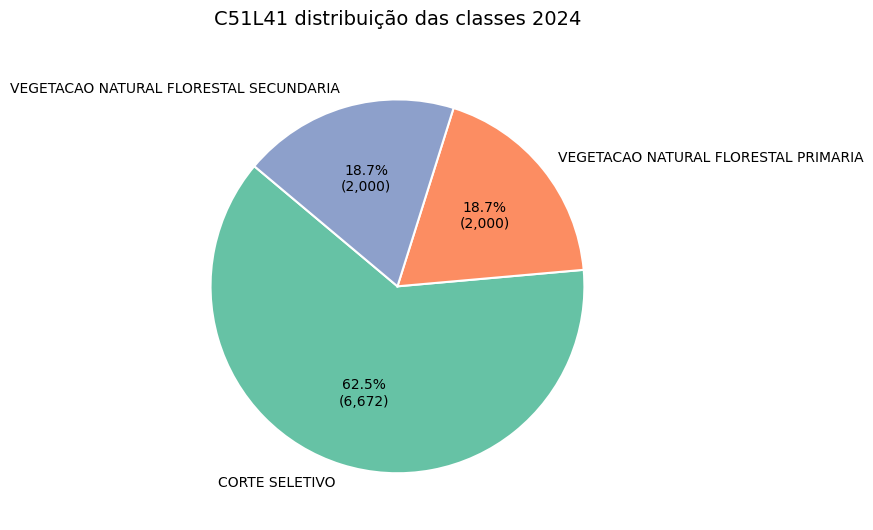

In [157]:
plot_balance(test_samples_points, "label", f"{test_tile_id} distribuição das classes {year}")

## ROI Tile 1

In [16]:
roi_tile_1_name = "tile_C51L34_Eco03_WGS84"
roi_tile_1 = gpd.read_file(f"{roi_tile_path}{roi_tile_1_name}.gpkg")
if roi_tile_1.crs != "EPSG:4326":
    roi_tile_1 = roi_tile_1.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = roi_tile_1.total_bounds
roi_tile_1_id = roi_tile_1.iloc[0]["id"]
roi_tile_1_id

'C51L34'

In [145]:
tile = roi_tile_1

roi_samples_tile_1_veg = extract_samples_from_tiff(da, mask, year, n_samples, tile)
roi_samples_tile_1_veg.head()

,year,label,tile,geometry
0,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L34,POINT (-61.17371 -9.89411)
1,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L34,POINT (-61.11926 -9.94487)
2,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L34,POINT (-61.09658 -9.98789)
3,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L34,POINT (-61.14941 -9.76577)
4,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C51L34,POINT (-61.07633 -9.90383)


In [158]:
label_mask = "CORTE SELETIVO"

roi_samples_tile_1_name = f"Aut_{roi_tile_1_id}_Eco03_CorteSeletivo_year"
roi_samples_tile_1 = gpd.read_file(f"{roi_tile_path}{roi_samples_tile_1_name}.gpkg")
roi_samples_tile_1["label"] = label_mask
roi_samples_tile_1["tile"] = roi_tile_1_id
roi_samples_tile_1 = roi_samples_tile_1[["year", "label", "tile", "geometry"]]
roi_samples_tile_1 = roi_samples_tile_1[roi_samples_tile_1["year"] == str(year)]

roi_samples_tile_1_veg = roi_samples_tile_1_veg.to_crs(roi_samples_tile_1.crs)
roi_samples_tile_1 = pd.concat([roi_samples_tile_1, roi_samples_tile_1_veg], ignore_index=True)

roi_samples_tile_1.to_csv(f"{samples_path}samples_{roi_tile_1_id}_{year}.csv", index=False)
roi_samples_tile_1.head()

,year,label,tile,geometry
0,2024,CORTE SELETIVO,C51L34,"POLYGON ((-61.2222 -9.9967, -61.2223 -9.9967, ..."
1,2024,CORTE SELETIVO,C51L34,"POLYGON ((-61.2223 -9.9966, -61.2225 -9.9966, ..."
2,2024,CORTE SELETIVO,C51L34,"POLYGON ((-61.2225 -9.9963, -61.2226 -9.9963, ..."
3,2024,CORTE SELETIVO,C51L34,"POLYGON ((-61.2224 -9.9963, -61.2224 -9.9962, ..."
4,2024,CORTE SELETIVO,C51L34,"POLYGON ((-61.2225 -9.9959, -61.2225 -9.9958, ..."


In [159]:
n_points_per_polygon = 1

roi_samples_tile_1_points = sample_points_in_polygons(roi_samples_tile_1, )
roi_samples_tile_1_points["year"] = year
roi_samples_tile_1_points["tile"] = roi_tile_1_id
roi_samples_tile_1_points = roi_samples_tile_1_points[["year", "label", "tile", "geometry"]]

roi_samples_tile_1_veg = roi_samples_tile_1_veg.to_crs(roi_samples_tile_1_points.crs)
roi_samples_tile_1_points = pd.concat([roi_samples_tile_1_points, roi_samples_tile_1_veg], ignore_index=True)

roi_samples_tile_1_points.to_csv(f"{samples_path}samples_{roi_tile_1_id}_{year}_points.csv", index=False)
roi_samples_tile_1_points.head()

,year,label,tile,geometry
0,2024,CORTE SELETIVO,C51L34,POINT (-61.22229 -9.99668)
1,2024,CORTE SELETIVO,C51L34,POINT (-61.22234 -9.99657)
2,2024,CORTE SELETIVO,C51L34,POINT (-61.22259 -9.99621)
3,2024,CORTE SELETIVO,C51L34,POINT (-61.22236 -9.99625)
4,2024,CORTE SELETIVO,C51L34,POINT (-61.22243 -9.99587)


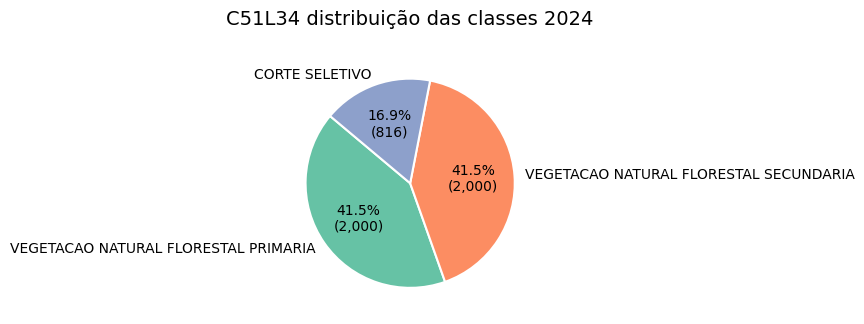

In [160]:
plot_balance(roi_samples_tile_1_points, "label", f"{roi_tile_1_id} distribuição das classes {year}")

## ROI Tile 2

In [22]:
roi_tile_2_name = "tile_C60L63_Eco01_WGS84"
roi_tile_2 = gpd.read_file(f"{roi_tile_path}{roi_tile_2_name}.gpkg")
if roi_tile_2.crs != "EPSG:4326":
    roi_tile_2 = roi_tile_2.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = roi_tile_2.total_bounds
roi_tile_2_id = roi_tile_2.iloc[0]["id"]
roi_tile_2_id

'C60L63'

In [148]:
tile = roi_tile_2

roi_samples_tile_2_veg = extract_samples_from_tiff(da, mask, year, n_samples, tile)
roi_samples_tile_2_veg.head()

,year,label,tile,geometry
0,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C60L63,POINT (-58.86368 -2.55821)
1,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C60L63,POINT (-58.98716 -2.67296)
2,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C60L63,POINT (-58.91057 -2.51249)
3,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C60L63,POINT (-58.84406 -2.68007)
4,2024,VEGETACAO NATURAL FLORESTAL PRIMARIA,C60L63,POINT (-58.79024 -2.71796)


In [161]:
label_mask = "CORTE SELETIVO"

roi_samples_tile_2_name = f"Aut_{roi_tile_2_id}_Eco01_CorteSeletivo"
roi_samples_tile_2 = gpd.read_file(f"{roi_tile_path}{roi_samples_tile_2_name}.gpkg")
roi_samples_tile_2["year"] = [str(dt.year) for dt in roi_samples_tile_2["date"]]
roi_samples_tile_2["label"] = label_mask
roi_samples_tile_2["tile"] = roi_tile_2_id
roi_samples_tile_2 = roi_samples_tile_2.drop(columns = ["doy_2020", "date"])
roi_samples_tile_2 = roi_samples_tile_2[["year", "label", "tile", "geometry"]]
roi_samples_tile_2 = roi_samples_tile_2[roi_samples_tile_2["year"] == str(year)]

roi_samples_tile_2_veg = roi_samples_tile_2_veg.to_crs(roi_samples_tile_2.crs)
roi_samples_tile_2 = pd.concat([roi_samples_tile_2, roi_samples_tile_2_veg], ignore_index=True)

roi_samples_tile_2.to_csv(f"{samples_path}samples_{roi_tile_2_id}_{year}.csv", index=False)
roi_samples_tile_2.head()

,year,label,tile,geometry
0,2024,CORTE SELETIVO,C60L63,"POLYGON ((-58.969 -2.5707, -58.9689 -2.5707, -..."
1,2024,CORTE SELETIVO,C60L63,"POLYGON ((-58.9612 -2.6828, -58.9612 -2.6827, ..."
2,2024,CORTE SELETIVO,C60L63,"POLYGON ((-58.9422 -2.6653, -58.9422 -2.6652, ..."
3,2024,CORTE SELETIVO,C60L63,"POLYGON ((-58.9421 -2.6651, -58.9421 -2.665, -..."
4,2024,CORTE SELETIVO,C60L63,"POLYGON ((-58.9699 -2.6557, -58.9699 -2.6556, ..."


In [162]:
n_points_per_polygon = 1

roi_samples_tile_2_points = sample_points_in_polygons(roi_samples_tile_2, n_points_per_polygon)
roi_samples_tile_2_points["year"] = year
roi_samples_tile_2_points["tile"] = roi_tile_2_id
roi_samples_tile_2_points = roi_samples_tile_2_points[["year", "label", "tile", "geometry"]]

roi_samples_tile_2_veg = roi_samples_tile_2_veg.to_crs(roi_samples_tile_2_points.crs)
roi_samples_tile_2_points = pd.concat([roi_samples_tile_2_points, roi_samples_tile_2_veg], ignore_index=True)

roi_samples_tile_2_points.to_csv(f"{samples_path}samples_{roi_tile_2_id}_{year}_points.csv", index=False)
roi_samples_tile_2_points.head()

,year,label,tile,geometry
0,2024,CORTE SELETIVO,C60L63,POINT (-58.96892 -2.57076)
1,2024,CORTE SELETIVO,C60L63,POINT (-58.96111 -2.6828)
2,2024,CORTE SELETIVO,C60L63,POINT (-58.94212 -2.66527)
3,2024,CORTE SELETIVO,C60L63,POINT (-58.94201 -2.66501)
4,2024,CORTE SELETIVO,C60L63,POINT (-58.96988 -2.65568)


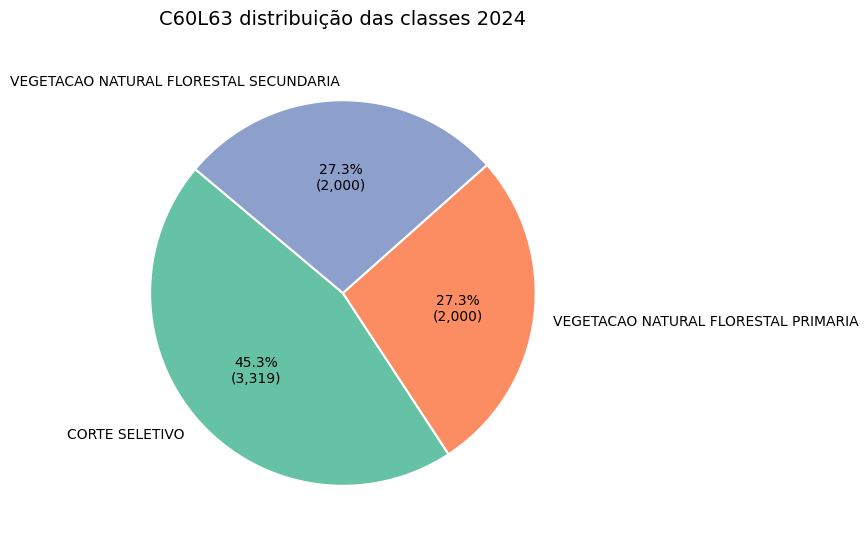

In [163]:
plot_balance(roi_samples_tile_2_points, "label", f"{roi_tile_2_id} distribuição das classes {year}")